(ch:ml-classification)=
# 분류 프로젝트

이 장에서는 UCI Machine Learning Repository의 레드 와인 품질 데이터셋을 이용하여 품질이 좋은 와인을 찾는 이진 분류 문제를 다룬다. 분류 모델을 훈련하기 전에 데이터의 구조와 분포를 충분히 살펴보고, 정확도뿐 아니라 혼동 행렬, 정밀도, 재현율을 함께 해석한다.

**기본 설정**

머신러닝 프로젝트에 필요한 기본 라이브러리를 불러온다. 

- `numpy`: 어레이 기반 데이터 처리
- `pandas`: 데이터프레임 기반 데이터 처리
- `matplotlib.pyplot`: 데이터 시각화
- `seaborn`: 통계 기반 데이터 시각화
- `sklearn`: 머신러닝 모델 훈련


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

seaborn 라이브러리의 기본 시각화 테마를 흰색 격자 배경을 사용하는 스타일로 지정한다.

In [2]:
sns.set_theme(style="whitegrid")

데이터프레임 내 부동소수점을 소수점 이하 6자리까지만 출력하도록 지정한다.

In [3]:
pd.set_option('display.precision', 6)

**데이터 저장소**

In [4]:
data_url = 'https://raw.githubusercontent.com/codingalzi/code-workout-datasci/refs/heads/master/data/'

## 프로젝트 흐름

분류 프로젝트의 진행 과정은 [회귀 프로젝트](#ch:ml-regression)와 기본적으로 동일하다. 보통 다음 순서로 진행된다.

1. 문제 정의
2. 모델 유형 확인
3. 데이터 적재
4. 데이터 구조 파악
5. 훈련셋과 테스트셋
6. 탐색적 데이터 분석
7. 전처리
8. 모델 선택과 훈련
9. 모델 평가

## 1단계: 문제 정의

**데이터셋**

와인 품질 데이터셋은 포르투갈 비뉴 베르드 레드 와인의 물리화학적 측정값과 시음 평가로 매긴 품질 점수를 담고 있다.

| 특성 | 설명 |
| :--- | :--- |
| `fixed acidity` | 고정 산도 |
| `volatile acidity` | 휘발성 산도 |
| `citric acid` | 구연산 함량 |
| `residual sugar` | 잔당 |
| `chlorides` | 염화물 함량 |
| `free sulfur dioxide` | 유리 이산화황 |
| `total sulfur dioxide` | 총 이산화황 |
| `density` | 밀도 |
| `pH` | 산성도 지표 |
| `sulphates` | 황산염 |
| `alcohol` | 알코올 도수 |
| `quality` | 품질 점수, 원래 타깃 |

**문제 정의**

`quality`가 7 이상인 와인을 `good`, 나머지를 `ordinary`로 정의하고, 이 두 클래스를 예측하는 분류 문제를 머신러닝 모델로 해결한다.

## 2단계: 모델 유형 확인

`quality` 값을 기준으로 와인을 `good` 또는 `ordinary` 중 하나로 구분하는 머신러닝 모델을 훈련시켜야 한다.
예측값은 두 개의 범주 중 하나이므로 이진 분류 과제에 해당한다.

이 과제를 해결하기 위해 분류용 머신러닝 모델을 선택하고, 와인 품질 데이터셋을 이용하여 모델을 훈련시킨다.
모델 훈련은 지도 학습 방식으로 진행된다.
이는 와인 품질 데이터셋에 정답에 해당하는 품질 레이블이 포함되어 있으며, 모델이 주어진 입력 특성을 바탕으로 와인의 품질 등급을 최대한 정확하게 예측하도록 학습하기 때문이다.

## 3단계: 데이터 적재

UCI에서 제공하는 CSV 파일을 읽고, 품질 점수를 기준으로 이진 타깃을 만든다. `head()`는 열 이름과 값의 형태를 빠르게 확인하는 데 도움이 된다.

In [5]:
wine_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine_df = pd.read_csv(wine_url, sep=";")

불러온 데이터는 다음과 같다.

In [6]:
wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 4단계: 데이터 구조 확인

데이터의 크기, 열의 자료형, 결측치, 기본 통계량, 타깃 클래스 구성을 확인한다.

와인 데이터셋은 총 1599개의 샘플과 12개의 특성으로 구성되었다.

In [7]:
wine_df.shape

(1599, 12)

각 열의 자료형과 결측치가 아닌 값의 수를 확인하면서 동시에 수치형 특성과 범주형 특성을 확인한다.
결측치는 전혀 없는 것으로 확인되며,
`quality` 특성 이외에는 모두 부동소수점을 값으로 갖는 수치형 특성이다.

In [8]:
wine_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


**`quality` 특성**

`quality` 특성은 1점과 10점 사이의 정수 품질 점수이며, 높은 값일 수록 좋은 품질을 의미하기에
수치형 특성으로 간주하는 게 원칙이다.
하지만 여기서는 7 이상을 `good`, 아니면 `ordinary` 두 특성으로 구분하는 용도로 사용하기에 수치형 특성 여부는 전혀 중요하지 않다.
먼저 `value_counts()` 메서드를 이용하여 어떤 점수가 몇 번씩 사용되었는지 확인한다.

In [ ]:
wine_df['quality'].value_counts().sort_index()

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

**수치형 특성**

`quality` 특성을 제외한 수치형 특성의 기본 통계량을 확인한다.
특성마다 값의 범위가 크게 다르면 표준화 등 일부 특성의 전처리가 필요할 수 있다.

In [9]:
wine_df.select_dtypes(include="float").describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000


수치형 특성별로 히스토그램을 통해 다음 정보를 얻을 수 있다.

- 각 특성마다 사용되는 단위와 스케일이 다르다. 1 미만 단위부터 백 단위까지 다양하다.
- 일부 특성은 한쪽으로 치우쳐저 있다. 
    특히 `residual sugar`, `chlorides`, `free sulfur dioxide`, `total sulfur dioxide`, 
    `sulphate`, `alcohol`은 오른쪽 꼬리가 길다.

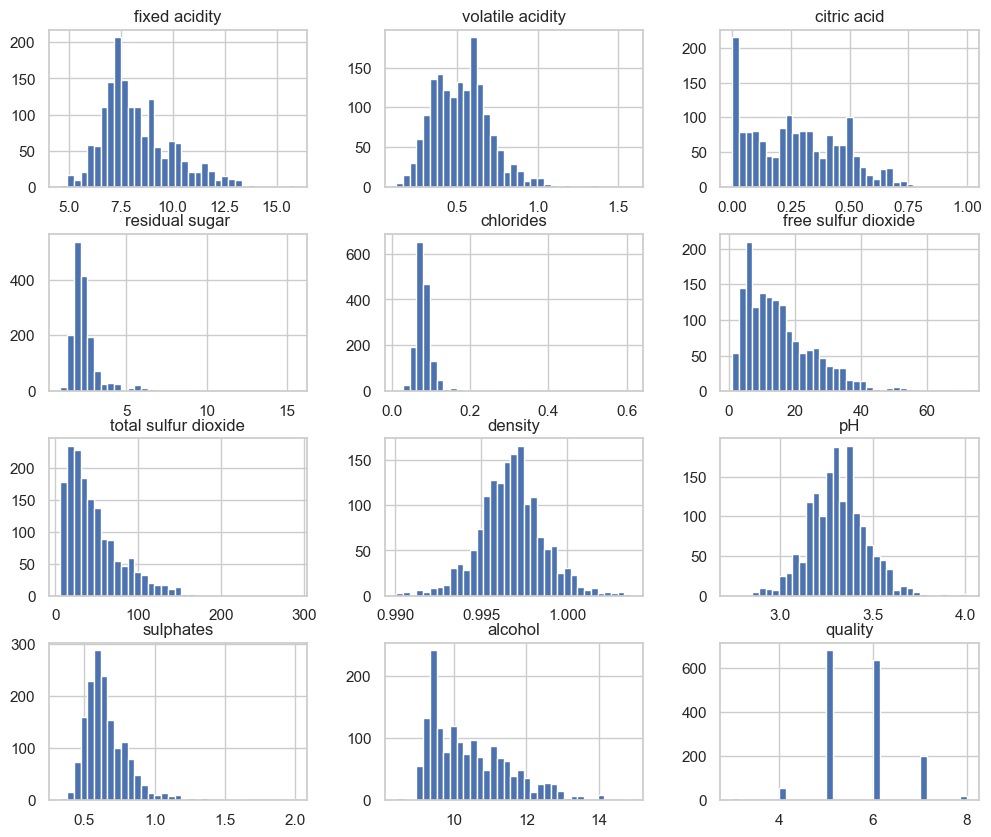

In [10]:
wine_df.hist(bins=35, figsize=(12, 10))
plt.show()

**훈련에 사용되는 특성**

`quality`가 7 이상인 와인을 구별해 내기 위해 `quality_label` 특성이 필요하다.
특성값은 `quality > 7`이면 `good`, 나머지를 `ordinary`로 지정된다.

In [12]:
wine_df["quality_label"] = (wine_df["quality"] >= 7).map({True: "good", False: "ordinary"})

`good` 범주와 `ordinaly` 범주는 각각 13.6%, 86.4%로 `ordinary` 범주가 압도적으로 많다.

In [13]:
wine_df["quality_label"].value_counts(normalize=True)

quality_label
ordinary    0.86429
good        0.13571
Name: proportion, dtype: float64

`quality`, `quality_label` 두 특성 이외의 다른 특성은 모델 훈련에 필요한 입력 특성으로 사용된다.

## 5단계: 훈련셋과 테스트셋

모델 훈련을 시작하기 전에 전체 데이터셋을 훈련셋과 테스트셋으로 나눈다.
훈련셋은 모델을 학습시키는 데 사용하고, 테스트셋은 훈련이 끝난 뒤 모델의 성능을 평가하는 데 사용한다.

`X`는 모델 입력에 사용할 특성값으로 구성된 데이터프레임이고, `y`는 예측 대상인 타깃 레이블로 구성된 시리즈이다.
아래 코드는 `train_test_split()` 함수를 이용하여 전체 데이터셋의 20%를 테스트셋으로 분리한다.
`stratify=y`는 타깃인 `quality_label`의 클래스 비율이 훈련셋과 테스트셋에서 비슷하게 유지되도록 층화 샘플링을 적용한다.
`good` 클래스가 상대적으로 적기 때문에, 단순 무작위 분할보다 층화 샘플링을 사용하는 편이 평가 결과를 더 안정적으로 해석하는 데 도움이 된다.

In [14]:
from sklearn.model_selection import train_test_split

X = wine_df.drop(columns=["quality", "quality_label"]) # 입력 특성 데이터셋
y = wine_df["quality_label"]                           # 타깃 레이블 데이터셋

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y,
                                                    test_size=0.2,
                                                    stratify=y,
                                                    random_state=42)

층화 샘플링으로 얻은 표본이 전체 데이터의 분포를 잘 반영하는지도 그래프로 확인할 수 있다.
아래에서는 전체 데이터셋과 층화 샘플링 방식으로 나눈 두 데이터셋을 비교한다.

In [15]:
quality_label_ratio = pd.DataFrame({
    "Full Dataset": wine_df["quality_label"].value_counts(normalize=True),
    "Train Set": y_train.value_counts(normalize=True),
    "Test Set": y_test.value_counts(normalize=True),
})

quality_label_ratio

,Full Dataset,Train Set,Test Set
quality_label,,,
ordinary,0.86429,0.863956,0.865625
good,0.13571,0.136044,0.134375


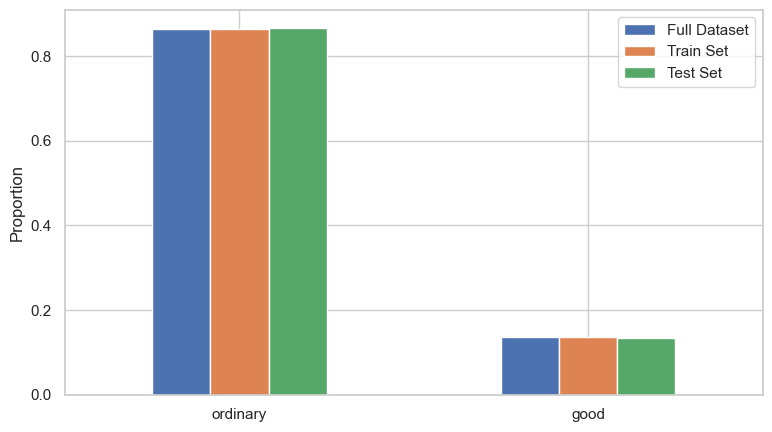

In [16]:
quality_label_ratio.plot.bar(rot=0, figsize=(9, 5))

plt.xlabel("")
plt.ylabel("Proportion")
plt.show()

## 6단계: 탐색적 데이터 분석

머신러닝 모델 훈련을 본격적으로 시작하기에 앞서 탐색적 데이터 분석(EDA)을 진행한다.
여기서는 다음 질문에 답해 본다.

> 물리화학적 측정값이 와인의 품질 등급 예측에 도움이 될까?

지금까지와 달리, 여기서는 훈련셋만을 대상으로 EDA를 진행한다.

:::{warning} 테스트셋 살펴보기

테스트셋을 훈련셋처럼 다양한 방식으로 살펴보는 일은 피해야 한다.
테스트셋은 훈련이 끝난 뒤 모델의 일반화 성능을 평가하기 위해 남겨 둔 데이터이므로,
모델을 선택하거나 분석 방향을 정하는 과정에서 사용하지 않는 것이 좋다.
:::

EDA에 사용할 훈련셋 데이터프레임을 준비한다.
`X_train`에는 모델 입력 특성만 포함되어 있으므로, 원래 품질 점수 `quality`와 이진 타깃 `quality_label`을 함께 붙여 분석용 데이터프레임을 만든다.

**데이터 불균형**

원래 품질 점수 분포와 이진 타깃 분포를 막대그래프로 확인하면, 점수 7 이상을 `good`으로 묶었을 때 두 클래스의 불균형이 어떻게 생기는지 시각적으로 확인할 수 있다.

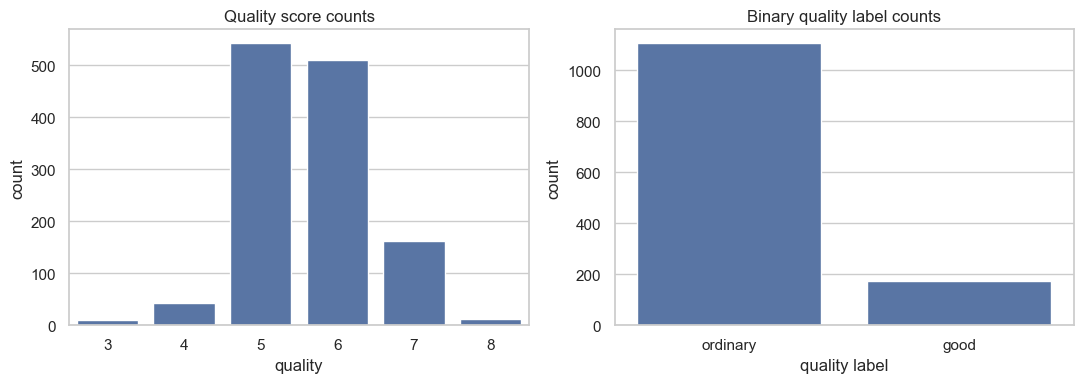

In [17]:
wine_train = X_train.copy()
wine_train["quality"] = wine_df.loc[X_train.index, "quality"]
wine_train["quality_label"] = y_train

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(data=wine_train, x="quality", ax=axes[0])
axes[0].set_title("Quality score counts")
axes[0].set_xlabel("quality")
axes[0].set_ylabel("count")

sns.countplot(data=wine_train, x="quality_label", order=["ordinary", "good"], ax=axes[1])
axes[1].set_title("Binary quality label counts")
axes[1].set_xlabel("quality label")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

전체 특성을 한꺼번에 살펴보기보다, 선행 연구와 변수 중요도 분석에서 품질 예측에 중요한 것으로 나타난 알코올 도수, 휘발성 산도, 황산염, 밀도를 먼저 살펴본다. 이 변수들은 각각 알코올 함량, 초산 계열 산도, 황산염 농도, 와인의 전체적인 조성에 따른 밀도를 측정한다.

In [18]:
selected_features = [
    "alcohol",
    "volatile acidity",
    "sulphates",
    "density",
]

wine_train[selected_features + ["quality", "quality_label"]].head()

,alcohol,volatile acidity,sulphates,density,quality,quality_label
440,9.8,0.31,0.82,0.99870,8,good
1146,9.8,0.50,0.87,0.99600,6,ordinary
229,11.0,0.52,0.50,0.99685,5,ordinary
838,11.2,0.31,0.83,0.99672,7,good
1579,11.3,0.56,0.60,0.99402,5,ordinary


**상자 그림**

선택한 특성의 클래스별 분포를 상자그림으로 비교한다.
상자그림은 두 클래스의 중앙값과 분포 범위가 어느 정도 다르고, 얼마나 겹치는지 보여준다.

그래프를 보면 `good` 와인은 `ordinary` 와인보다 알코올 도수와 황산염 값이 전반적으로 높은 편이다.
반대로 휘발성 산도와 밀도는 `good` 와인에서 상대적으로 낮은 경향을 보인다.

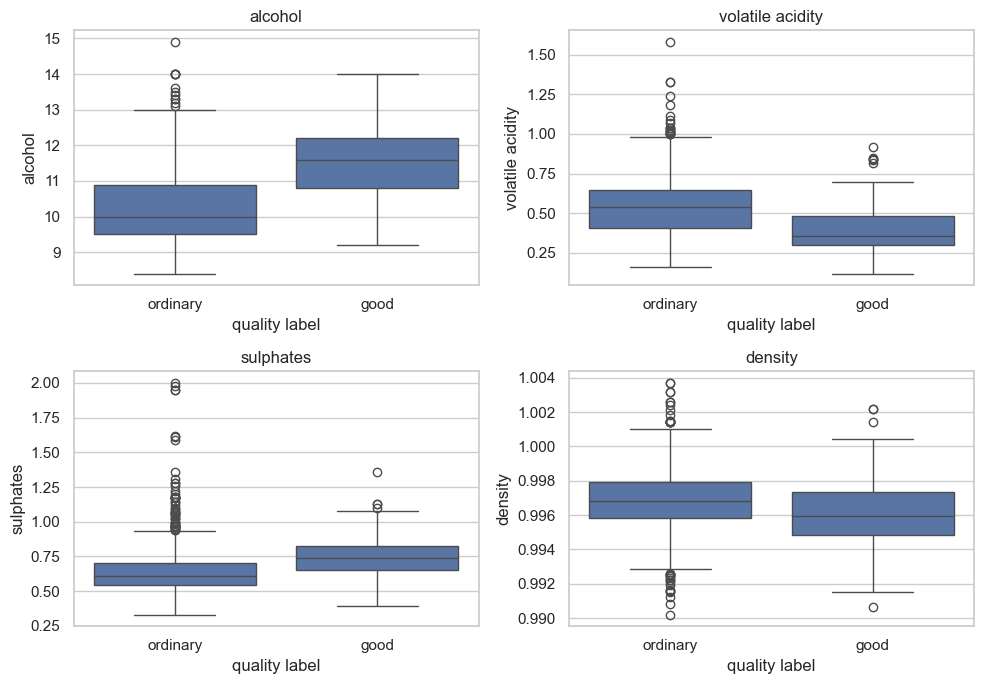

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for feature, ax in zip(selected_features, axes.ravel()):
    sns.boxplot(data=wine_train, x="quality_label", y=feature, order=["ordinary", "good"], ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("quality label")

plt.tight_layout()
plt.show()

**산점도**

알코올 도수와 휘발성 산도의 조합을 산점도로 확인한다.
한 개 특성만 볼 때보다 두 특성을 함께 보았을 때 `good` 와인이 모이는 경향이 있는지 파악할 수 있다.

산점도를 보면 `good` 와인은 대체로 알코올 도수가 높고 휘발성 산도가 낮은 영역에 비교적 많이 분포한다.
특히 알코올 도수가 11 이상이면서 휘발성 산도가 0.5 이하인 구간에서 `good` 샘플이 눈에 띈다.
하지만 같은 영역에도 `ordinary` 와인이 함께 존재하므로, 두 특성만으로 두 클래스를 완전히 분리하기는 어렵다.

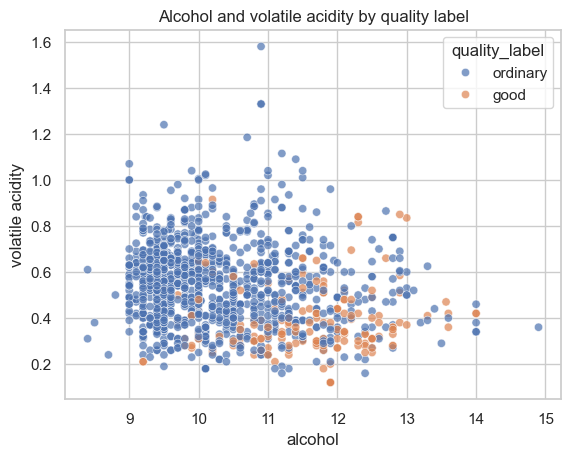

In [20]:
sns.scatterplot(
    data=wine_train,
    x="alcohol",
    y="volatile acidity",
    hue="quality_label",
    hue_order=["ordinary", "good"],
    alpha=0.7,
)
plt.title("Alcohol and volatile acidity by quality label")
plt.show()

**상관 계수**

훈련셋의 수치형 특성들과 원래 품질 점수 사이의 상관계수를 히트맵으로 시각화한다.
상관계수는 선형적인 관계를 요약하므로, 품질과 관련이 큰 후보 특성을 찾는 출발점으로 사용할 수 있다.

히트맵에서는 품질 점수와 각 수치형 특성의 관계뿐만 아니라 입력 특성들 사이의 관계도 함께 확인할 수 있다.
예를 들어 `fixed acidity`와 `citric acid`, `fixed acidity`와 `density`처럼 서로 관련이 큰 특성 쌍이 있으며, 이런 관계는 모델 해석이나 특성 선택을 고민할 때 참고할 수 있다.

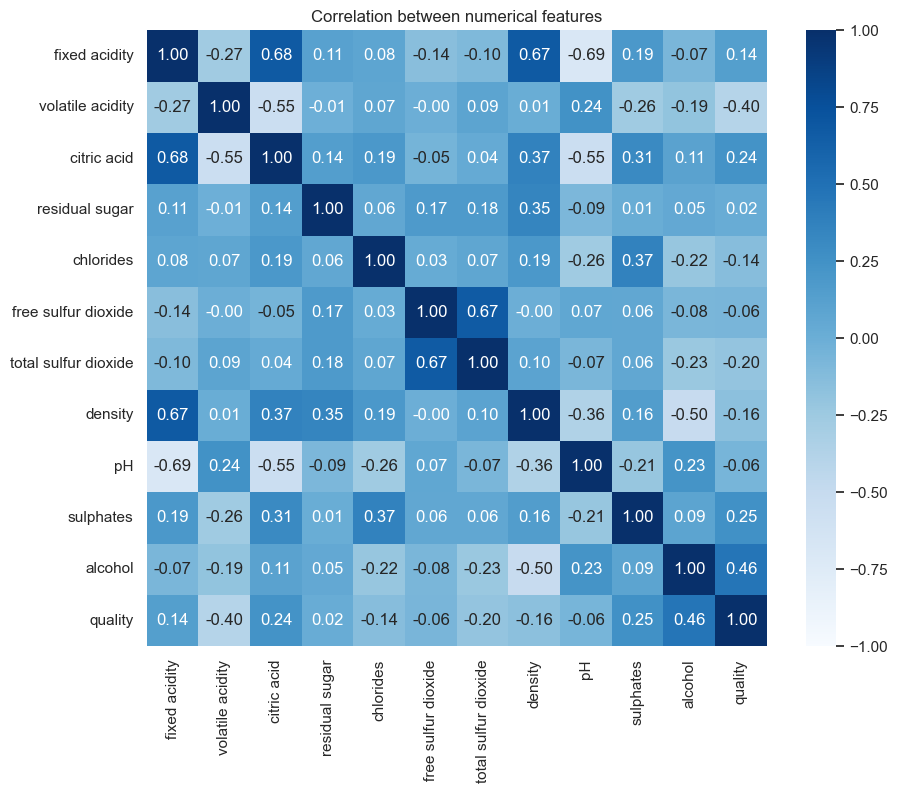

In [21]:
corr = wine_train.drop(columns="quality_label").corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1)
plt.title("Correlation between numerical features")
plt.show()

품질 점수와 각 특성의 상관계수만 따로 정렬하면 어떤 특성이 상대적으로 강한 양의 관계 또는 음의 관계를 갖는지 더 쉽게 비교할 수 있다.
단, 상관관계만으로 품질을 결정하는 원인이라고 결론 내릴 수는 없다.

훈련셋에서는 `alcohol`이 품질 점수와 가장 큰 양의 상관관계를 보이고, `sulphates`와 `citric acid`도 양의 상관관계를 보인다.
반대로 `volatile acidity`는 가장 큰 음의 상관관계를 보이며, `total sulfur dioxide`, `density`, `chlorides`도 품질 점수와 음의 관계를 보인다.

In [22]:
quality_correlation = (
    corr["quality"]
    .drop("quality")
    .sort_values()
    .rename("correlation_with_quality")
)

quality_correlation.to_frame()

,correlation_with_quality
volatile acidity,-0.397158
total sulfur dioxide,-0.195563
density,-0.162585
chlorides,-0.135432
free sulfur dioxide,-0.064288
pH,-0.061437
residual sugar,0.020396
fixed acidity,0.137081
citric acid,0.238247
sulphates,0.250265


훈련셋을 대상으로 한 EDA 결과에서 다음을 확인할 수 있다.

- 품질 점수가 7 이상인 `good` 와인은 `ordinary` 와인보다 적어 클래스 불균형이 존재한다.
- `good` 와인은 `ordinary` 와인보다 알코올 도수와 황산염 값이 상대적으로 높은 경향을 보인다.
- `volatile acidity`는 품질 점수와 가장 뚜렷한 음의 상관관계를 보이며, `good` 와인에서 상대적으로 낮은 경향을 보인다.
- `density`, `chlorides`, `total sulfur dioxide`도 품질 점수와 음의 관계를 보이지만, 관계의 크기는 `volatile acidity`보다 작다.
- 각 클래스의 분포가 완전히 분리되지는 않으므로 여러 특성을 함께 사용하는 분류 모델이 필요하다.

## 7단계: 전처리 파이프라인

일부 머신러닝 모델은 입력 특성의 스케일이 비슷할 때 더 안정적으로 학습된다. 이전 [회귀 프로젝트](#ch:ml-regression)에서는 펭귄의 신체 측정값을 표준화하여 확률적 경사 하강법 모델의 성능을 크게 향상시켰다.

분류 모델에서도 특성의 스케일을 통일하면 학습 안정성과 성능이 향상될 수 있다. 특히 로지스틱 회귀는 특성 스케일의 영향을 많이 받는다. 반면 랜덤 포레스트는 특성값의 상대적인 순서를 기준으로 데이터를 분할하므로 일반적으로 표준화의 영향을 거의 받지 않는다.

이전 장에서는 입력 데이터를 미리 표준화한 뒤 모델 훈련에 사용하였다. 여기서는 표준화와 함께 일부 특성에 로그 변환을 적용하고, 이러한 전처리 단계와 모델을 하나의 파이프라인으로 구성한다. 이를 통해 각 모델에 필요한 전처리만 선택적으로 적용할 수 있다.

**로그 변환**

아래 코드는 오른쪽 꼬리가 긴 여섯 특성에 `log1p`를 적용한 뒤 히스토그램을 다시 그린다. 
`log1p(x)`는 `log(1+x)`를 계산하여 큰 값을 상대적으로 많이 압축하므로 치우친 분포를 완화할 수 있다.
`1+x`처럼 1을 더한 뒤 로그를 계산하므로 값이 0인 경우에도 사용할 수 있다. 

로그 변환은 큰 값과 값 사이의 간격을 더 강하게 압축하여 소수의 매우 큰 값이 모델 학습에 미치는 영향을 줄인다. 그 결과 작은 값들의 차이가 큰 값들의 차이에 비해 상대적으로 더 잘 드러날 수 있다.
변환 전 히스토그램과 비교하면 각 특성의 오른쪽 꼬리가 얼마나 줄어드는지 확인할 수 있다.

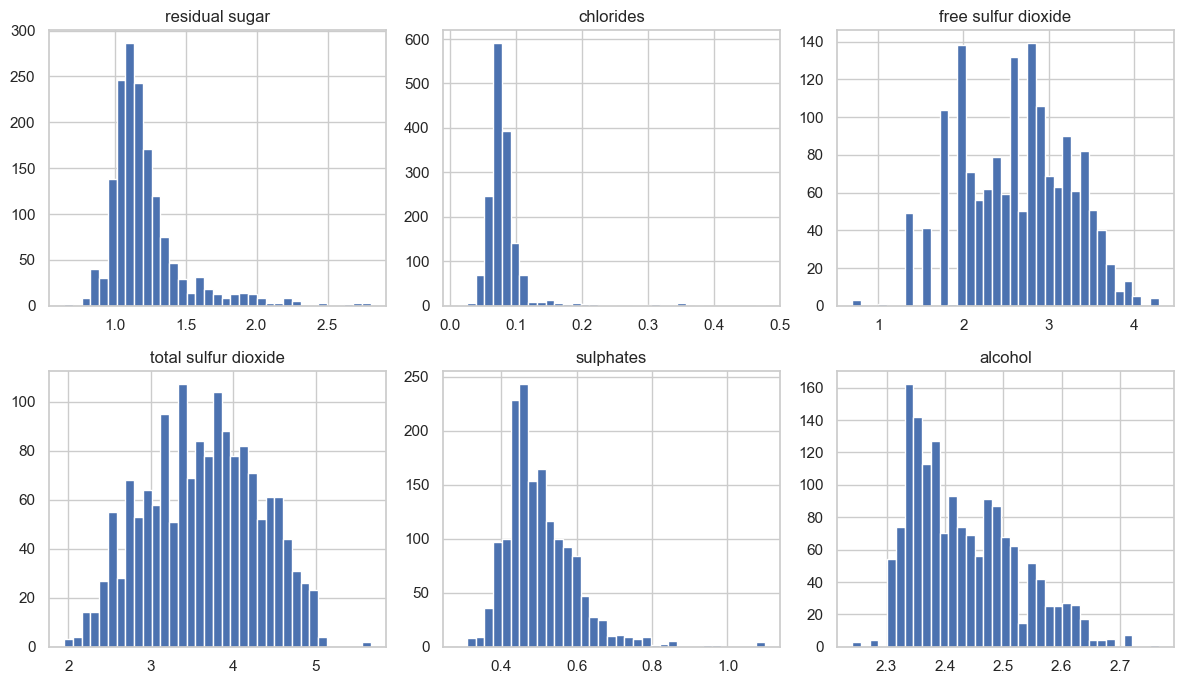

In [ ]:
log_features = [
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "sulphates",
    "alcohol",
]

wine_log = np.log1p(wine_df[log_features])

wine_log.hist(bins=35, figsize=(12, 7), layout=(2, 3))
plt.tight_layout()
plt.show()

**변환 파이프라인**

이제 로그 변환과 표준화를 하나의 전처리기 `preprocessor`로 구성한다. 특성마다 필요한 변환이 다르므로 모든 특성에 같은 변환을 적용하지 않고 아래 표에서처럼 두 그룹으로 나눈다.

| 대상 특성 | 적용 변환 | 파이프라인 구성 |
| :--- | :--- | :--- |
| `residual sugar`, `chlorides`, `free sulfur dioxide`, `total sulfur dioxide`, `sulphates`, `alcohol` | `log1p` 로그 변환 → 표준화 | `log_pipeline` |
| 나머지 특성 | 표준화 | `remainder=StandardScaler()` |

아래 코드에서 `preprocessor`는 표에 언급된 변환을 동시에 처리하는 전처리 변환기를 가리킨다. 

1. `log_features`: 로그 변환이 필요한 여섯 특성의 이름을 가리킨다.
2. `log_pipeline`: 
    - `FunctionTransformer(np.log1p)`는 넘파이 함수인 `np.log1p`를 사이킷런의 전처리 단계로 사용할 수 있게 감싼다. 
    - `make_pipeline()`은 로그 변환과 `StandardScaler`를 연결한다.
3. `preprocessor`:
    - `ColumnTransformer`는 열 그룹별로 서로 다른 전처리를 적용한다. 
        - `transformers`에 지정한 여섯 특성에는 `log_pipeline`을 적용한다.
        - 여기에 포함되지 않은 나머지 특성에는 `remainder=StandardScaler()`를 통해 표준화만 적용한다.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

# 로그 변환이 필요한 특성 목록
log_features = [
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "sulphates",
    "alcohol",
]

# 로그 변환과 표준화가 포함된 파이프라인
log_pipeline = make_pipeline(
    FunctionTransformer(np.log1p),  # 로그 변환
    StandardScaler(),               # 표준화
)

# 전체 특성에 대해 로그 변환과 표준화를 적용하는 ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[("log", log_pipeline, log_features)],
    remainder=StandardScaler(),
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",StandardScaler()
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{

`preprocessor`는 로그 변환과 표준화를 처리하는 전처리 변환기 객체이다. 위 코드는 변환 규칙을 구성하기만 하며 아직 실제 데이터를 변환하거나 표준화에 필요한 평균과 표준편차를 계산하지 않는다.

이후 `preprocessor`를 예측 모델과 하나의 파이프라인으로 연결하고 파이프라인의 `fit(X_train, y_train)`을 호출하면, 먼저 훈련셋의 모든 특성에 지정된 전처리를 적용한 다음 변환된 데이터로 예측 모델을 훈련한다. 따라서 전처리와 모델 훈련을 하나의 과정으로 묶을 수 있으며, 예측할 때도 훈련셋에서 학습한 것과 동일한 전처리가 자동으로 적용된다.

## 8단계: 모델 선택과 훈련

분류 모델로 로지스틱 회귀와 랜덤 포레스트를 사용한다. 두 모델은 데이터를 학습하는 방식과 전처리의 필요성이 서로 다르다.

| 모델 | 학습 방식 | 전처리 |
| :--- | :--- | :--- |
| 로지스틱 회귀 | 입력 특성의 선형 결합으로 클래스 확률 추정 | 로그 변환과 표준화 적용 |
| 랜덤 포레스트 | 여러 결정 트리의 예측을 결합 | 별도의 전처리 없이 원본 특성 사용 |

두 모델 모두 같은 훈련셋으로 학습한 뒤 테스트셋에서 성능을 비교한다.

### 로지스틱 회귀

로지스틱 회귀는 각 특성에 가중치를 곱한 선형 결합을 이용하여 샘플이 특정 클래스에 속할 확률을 추정한다. 특성의 스케일 차이에 영향을 받으므로 앞서 만든 `preprocessor`와 모델을 하나의 파이프라인으로 연결한다.

`fit()`을 호출하면 파이프라인이 훈련셋으로 전처리 기준을 학습하고, 변환된 데이터를 로지스틱 회귀 모델에 전달하여 연속해서 훈련한다.

In [31]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = make_pipeline(
    preprocessor,
    LogisticRegression(),
)

logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",StandardScaler()
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

### 랜덤 포레스트

랜덤 포레스트는 훈련셋에서 여러 표본을 무작위로 추출하고, 각 표본으로 학습한 결정 트리의 예측을 결합하는 앙상블 모델이다. 개별 트리는 특성값의 상대적인 순서를 기준으로 데이터를 분할하므로 표준화의 영향을 받지 않는다. `log1p`도 값의 순서를 바꾸지 않는 단조 변환이므로 여기서는 전처리 파이프라인을 적용하지 않는다.

In [32]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
)

forest_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 9단계: 모델 평가

### 로지스틱 회귀 평가

먼저 로지스틱 회귀 파이프라인으로 테스트셋의 클래스를 예측한다. 파이프라인의 `predict()`를 호출하면 훈련셋에서 학습한 전처리 기준이 테스트셋에 적용된 뒤 로지스틱 회귀 모델이 예측을 수행한다.

정확도는 전체 샘플 중 올바르게 분류한 샘플의 비율이다. 모델의 전반적인 성능을 간단히 나타내지만, `ordinary`가 많은 불균형 데이터에서는 소수 클래스인 `good`을 제대로 찾지 못해도 높게 나타날 수 있다. 따라서 혼동 행렬, 정밀도, 재현율을 함께 확인해야 한다.

In [33]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
)

logistic_pred = logistic_pipeline.predict(X_test)
logistic_accuracy = accuracy_score(y_test, logistic_pred)

logistic_accuracy

0.8875

**혼동 행렬**

혼동 행렬은 실제 클래스와 예측 클래스의 조합별 샘플 수를 보여준다. 행은 실제 클래스, 열은 예측 클래스를 나타낸다.

| 실제 클래스 | 예측 클래스 | 의미 |
| :--- | :--- | :--- |
| `ordinary` | `ordinary` | 일반 와인을 올바르게 분류 |
| `ordinary` | `good` | 일반 와인을 좋은 와인으로 잘못 분류 |
| `good` | `ordinary` | 좋은 와인을 놓침 |
| `good` | `good` | 좋은 와인을 올바르게 찾음 |

특히 실제 `good`을 `ordinary`로 예측한 값은 모델이 놓친 좋은 와인의 수를 나타낸다.

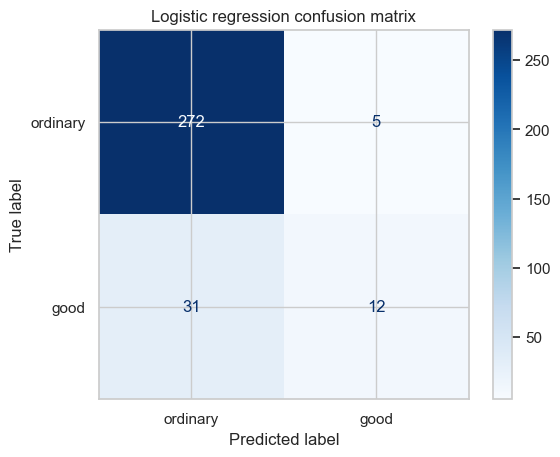

In [34]:
labels = ["ordinary", "good"]
logistic_cm = confusion_matrix(y_test, logistic_pred, labels=labels)

ConfusionMatrixDisplay(logistic_cm, display_labels=labels).plot(cmap="Blues")
plt.title("Logistic regression confusion matrix")
plt.show()

**정밀도와 재현율**

정밀도는 모델이 특정 클래스로 예측한 샘플 중 실제로 그 클래스인 비율이고, 재현율은 실제로 특정 클래스인 샘플 중 모델이 찾아낸 비율이다.

| 평가 지표 | `good` 클래스에서의 질문 |
| :--- | :--- |
| 정밀도 | 좋은 와인이라고 예측한 것 중 실제 좋은 와인은 얼마나 되는가? |
| 재현율 | 실제 좋은 와인 중 모델이 찾아낸 것은 얼마나 되는가? |
| F1 점수 | 정밀도와 재현율이 얼마나 균형을 이루는가? |

좋은 와인을 추천 대상으로 엄선하려면 `good` 정밀도가 중요할 수 있다. 반대로 좋은 와인을 최대한 놓치지 않는 것이 목적이라면 `good` 재현율을 더 중요하게 볼 수 있다. `classification_report()`는 클래스별 정밀도, 재현율, F1 점수와 샘플 수를 함께 보여준다.

In [35]:
print(classification_report(y_test, logistic_pred, labels=labels))

              precision    recall  f1-score   support

    ordinary       0.90      0.98      0.94       277
        good       0.71      0.28      0.40        43

    accuracy                           0.89       320
   macro avg       0.80      0.63      0.67       320
weighted avg       0.87      0.89      0.87       320



**예측 확률**

로지스틱 회귀는 클래스뿐만 아니라 각 클래스에 속할 확률도 추정한다. 테스트셋의 일부 결과를 실제 클래스, 예측 클래스, `good`일 예측 확률과 함께 정리한다. 확률을 확인하면 모델이 어느 예측에 높은 확신을 보였는지 살펴볼 수 있으며, 필요하면 `good`으로 분류하는 기준 확률을 조정할 수도 있다.

In [36]:
good_index = list(logistic_pipeline.classes_).index("good")

logistic_results = pd.DataFrame({
    "actual": y_test,
    "predicted": logistic_pred,
    "probability_good": logistic_pipeline.predict_proba(X_test)[:, good_index],
})

logistic_results.head(10)

,actual,predicted,probability_good
282,ordinary,ordinary,0.009258
133,ordinary,ordinary,0.031006
39,ordinary,ordinary,0.087536
504,good,good,0.569580
1589,ordinary,ordinary,0.007215
283,good,ordinary,0.124256
495,good,ordinary,0.330970
590,ordinary,ordinary,0.016784
755,ordinary,ordinary,0.010216
761,ordinary,ordinary,0.004762


### 랜덤 포레스트와 비교

랜덤 포레스트도 같은 테스트셋을 예측하게 한 뒤 로지스틱 회귀와 정확도, `good` 정밀도, `good` 재현율을 비교한다. 같은 데이터 분할을 사용해야 두 모델의 차이를 공정하게 비교할 수 있다.

In [37]:
forest_pred = forest_model.predict(X_test)

model_comparison = pd.DataFrame({
    "accuracy": [
        logistic_accuracy,
        accuracy_score(y_test, forest_pred),
    ],
    "good_precision": [
        precision_score(y_test, logistic_pred, pos_label="good"),
        precision_score(y_test, forest_pred, pos_label="good"),
    ],
    "good_recall": [
        recall_score(y_test, logistic_pred, pos_label="good"),
        recall_score(y_test, forest_pred, pos_label="good"),
    ],
}, index=["logistic regression", "random forest"])

model_comparison

,accuracy,good_precision,good_recall
logistic regression,0.887500,0.705882,0.279070
random forest,0.921875,0.846154,0.511628


랜덤 포레스트의 혼동 행렬과 분류 보고서도 확인한다. 두 모델의 정확도가 비슷하더라도 `good` 정밀도와 재현율은 다를 수 있으므로, 모델의 사용 목적에 맞는 지표를 기준으로 비교해야 한다.

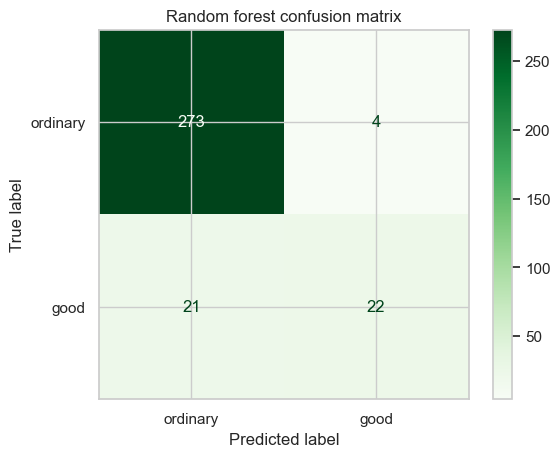

              precision    recall  f1-score   support

    ordinary       0.93      0.99      0.96       277
        good       0.85      0.51      0.64        43

    accuracy                           0.92       320
   macro avg       0.89      0.75      0.80       320
weighted avg       0.92      0.92      0.91       320



In [38]:
forest_cm = confusion_matrix(y_test, forest_pred, labels=labels)

ConfusionMatrixDisplay(forest_cm, display_labels=labels).plot(cmap="Greens")
plt.title("Random forest confusion matrix")
plt.show()

print(classification_report(y_test, forest_pred, labels=labels))

### 랜덤 포레스트의 특성 중요도

랜덤 포레스트는 각 특성이 트리의 분할 과정에서 불순도를 얼마나 감소시켰는지를 바탕으로 `feature_importances_`를 계산한다. 값이 클수록 모델이 예측 과정에서 해당 특성을 많이 활용했다는 뜻이다.

랜덤 포레스트에는 원본 데이터프레임을 그대로 입력했으므로 `feature_importances_`의 순서는 `X_train.columns`의 특성 순서와 같다. 두 배열을 연결하여 특성별 중요도를 확인한다.

특성 중요도는 모델의 예측에 기여한 상대적인 정도이며 인과관계를 의미하지 않는다. 또한 서로 강하게 연관된 특성이 있으면 중요도가 여러 특성으로 나뉘어 나타날 수 있다.

In [39]:
feature_importance = (
    pd.Series(
        forest_model.feature_importances_,
        index=X_train.columns,
        name="importance",
    )
    .sort_values(ascending=False)
)

feature_importance.to_frame()

,importance
alcohol,0.169625
volatile acidity,0.114177
sulphates,0.113714
citric acid,0.098103
density,0.090099
total sulfur dioxide,0.075983
fixed acidity,0.074947
chlorides,0.072336
residual sugar,0.066155
pH,0.062525


특성 중요도를 막대그래프로 나타내면 랜덤 포레스트가 상대적으로 많이 활용한 특성을 쉽게 비교할 수 있다.

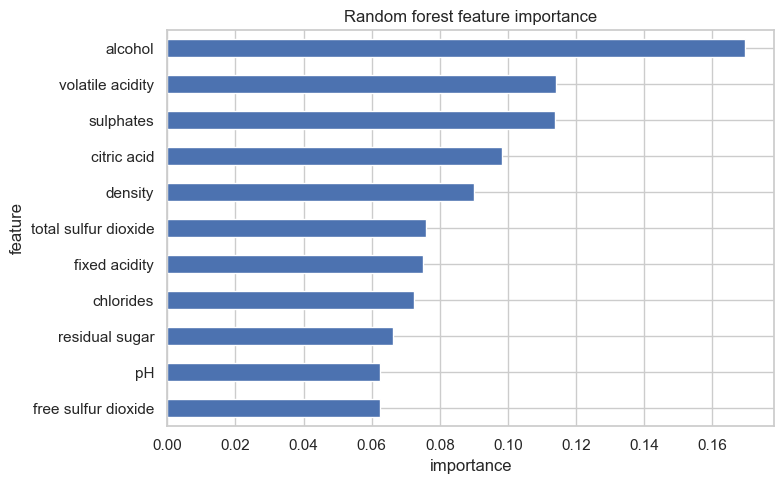

In [40]:
feature_importance.sort_values().plot.barh(figsize=(8, 5))
plt.title("Random forest feature importance")
plt.xlabel("importance")
plt.ylabel("feature")
plt.tight_layout()
plt.show()

## 정리

이번 장에서는 와인 품질 데이터셋으로 이진 분류 프로젝트의 기본 흐름을 살펴보았다.

- 데이터 구조와 결측치, 통계량을 확인한 뒤 모델링을 시작한다.
- EDA를 통해 타깃 클래스의 불균형과 후보 특성의 분포 차이를 파악할 수 있다.
- 이진 분류는 두 클래스 중 하나를 예측하는 문제이다.
- 로그 변환과 표준화를 전처리 파이프라인으로 구성하면 훈련과 예측에 같은 변환을 일관되게 적용할 수 있다.
- 클래스 비율이 치우친 데이터에서는 정확도만으로 모델을 평가하기 어렵다.
- 혼동 행렬, 정밀도, 재현율을 함께 보면 모델이 어떤 실수를 하는지 이해할 수 있다.
- 로지스틱 회귀와 랜덤 포레스트처럼 학습 방식이 다른 모델을 같은 테스트셋에서 비교할 수 있다.
- 랜덤 포레스트의 특성 중요도를 이용하면 모델이 예측에 많이 활용한 특성을 확인할 수 있다.

실제 품질 판별 문제에서는 임계값 조정, 클래스 가중치, 추가 모델 비교 등을 통해 `good` 와인을 찾는 성능을 더 면밀히 개선할 수 있다.

## 연습문제

**문제 1**

로지스틱 회귀와 랜덤 포레스트의 정확도, `good` 정밀도, `good` 재현율을 비교해 보아라. 어떤 모델이 좋은 와인을 더 많이 찾아내는가?

**문제 2**

혼동 행렬에서 모델이 좋은 와인을 얼마나 놓치는지 설명해 보아라. 이 문제에서 좋은 와인을 놓치는 실수가 중요한 이유는 무엇인가?

**문제 3**

`classification_report()`에서 `good`과 `ordinary`의 정밀도와 재현율을 비교해 보아라. 클래스 불균형과 어떤 관련이 있는가?

**문제 4**

랜덤 포레스트의 특성 중요도에서 상위 특성을 확인하고, EDA에서 관찰한 품질과의 관계와 비교해 보아라.

**문제 5**

`quality >= 6`으로 좋은 와인의 기준을 바꾸면 클래스 분포와 두 모델의 평가 결과는 어떻게 달라지는가?